# Regularization in Logistic Regression


# 🎬 Chapter 12 — When Milo Starts Memorizing Instead of Learning



## 🎭 Characters

👩 Riya
👨‍🏫 Professor Arjun
🤖 Milo

---

# 🌅 Classroom Situation

Professor Arjun trains Milo with student data.

Dataset:

| Hours | Result |
| ----- | ------ |
| 1     | Fail   |
| 2     | Fail   |
| 3     | Fail   |
| 4     | Pass   |
| 5     | Pass   |
| 6     | Pass   |

Milo learns nicely.

But then something strange happens.

---





# 📉 Problem: Overfitting

Milo starts **memorizing instead of learning patterns**.

Imagine this curve:

![Image](https://miro.medium.com/1%2A_7OPgojau8hkiPUiHoGK_w.png)

![Image](https://docs.aws.amazon.com/images/machine-learning/latest/dg/images/mlconcepts_image5.png)

![Image](https://developers.google.com/static/machine-learning/crash-course/images/metric-curve-ex01.svg)

![Image](https://storage.googleapis.com/kaggle-media/learn/images/eP0gppr.png)

Three situations:

| Model        | Meaning                    |
| ------------ | -------------------------- |
| Underfitting | Too simple, learns nothing |
| Good Fit     | Learns pattern correctly   |
| Overfitting  | Memorizes noise            |

---

### Overfitting Example

Instead of learning:

```text
More study → more chance to pass
```

Milo memorizes:

```text
3 hours → fail
3.1 hours → pass
3.2 hours → fail
```

Which is **nonsense**.

---

# 🧠 Why Overfitting Happens

Because the model parameters become **too large**.

Logistic regression equation:

```
z = w1*x1 + w2*x2 + b
```

If weights become:

```
w1 = 120
w2 = -95
```

The curve becomes **too steep and unstable**.

---

# 🚑 Solution — Regularization

Professor Arjun says:

> "Milo, calm down. Don't use huge weights."

Regularization means:

```text
Punish large weights
```

So the model stays **simple and stable**.

---

# 🧠 Regularization Idea (Simple)

Old loss function:

```
Loss = Log Loss
```

New loss function:

```
Loss = Log Loss + Penalty
```

Penalty increases if weights become **too large**.

So if the model tries to create **very large weights**, the loss increases.

The algorithm therefore prefers **smaller, simpler weights**.
---

# 🧮 Two Types of Regularization

| Type | Name  |
| ---- | ----- |
| L1   | Lasso |
| L2   | Ridge |

---

# 1️⃣ L2 Regularization (Most Common)

Equation becomes:

```
Loss = LogLoss + λ(w1² + w2² + w3²...)
```

Explanation:


| Symbol     | Meaning                 |
| ---------- | ----------------------- |
| λ (lambda) | regularization strength |
| w          | model weights           |

If weights become large → penalty becomes large.

So the model **keeps weights small**.

---

# 📊 Visual Intuition

![Image](https://miro.medium.com/v2/resize%3Afit%3A1278/0%2AMuVvxE8pkBLtPzrx)

![Image](https://www.researchgate.net/publication/385495113/figure/fig1/AS%3A11431281288259019%401730636231814/Contour-Plots-for-the-Ridge-LASSO-and-Elastic-Net-Regression-estimators-illustrates-the.png)

![Image](https://miro.medium.com/v2/resize%3Afit%3A1212/0%2AJbWKTQY9GB66y6hR)

![Image](https://api.wandb.ai/files/mostafaibrahim17/images/projects/37042936/fe55e721.png)

Effect:

```text
Large weights → shrink toward zero
```

But **never exactly zero**.
If weights become large → penalty becomes large.
---

# 2️⃣ L1 Regularization

Equation:

```
Loss = LogLoss + λ(|w1| + |w2| + |w3|)
```

Instead of squaring weights, we use **absolute values**.

Some weights become **exactly zero**.

This means the model automatically **removes unnecessary features**.
---

# 📊 Visual Intuition

![Image](https://i.stack.imgur.com/oVJDB.png)

![Image](https://www.researchgate.net/publication/351848547/figure/fig2/AS%3A11431281256328941%401719525185029/Feature-selection-using-the-LASSO-regression-analysis-A-LASSO-coefficient-profiles-of.jpg)

![Image](https://api.wandb.ai/files/mostafaibrahim17/images/projects/37042936/fe55e721.png)

![Image](https://media.licdn.com/dms/image/v2/C4D12AQEgtRRdCc0GTQ/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1558564556609?e=2147483647\&t=rsmsQx7JBdmq166bVI2AtkIu7JbmG7aqMN4B7K_GB9s\&v=beta)

Effect:

```text
Some weights become exactly zero
```

Meaning:

The model **removes useless features automatically**.

---

# ⚖️ Difference Between L1 and L2

| Feature             | L1   | L2   |
| ------------------- | ---- | ---- |
| Weight shrinking    | Yes  | Yes  |
| Weights become zero | Yes  | No   |
| Feature selection   | Yes  | No   |
| Most commonly used  | Less | More |

---

# 🤖 How Scikit-Learn Uses Regularization





In Scikit-Learn:

Regularization is controlled by **C**.

Important:

```
C = 1 / λ
```

Meaning:

| C value | Effect                |
| ------- | --------------------- |
| Large C | Weak regularization   |
| Small C | Strong regularization |

---


# 🧪 Step 1 — Import Libraries


In [ ]:
# Import numpy
# numpy is used for working with numerical data and arrays
import numpy as np


# Import matplotlib
# matplotlib helps us draw graphs and visualize data
import matplotlib.pyplot as plt


# Import Logistic Regression model from sklearn
# This model will learn the relationship between input and output
from sklearn.linear_model import LogisticRegression

# 🧪 Step 2 — Create Dataset


In [3]:
# Create an array representing hours studied by students
hours = np.array([1,2,3,4,5,6,7,8])


# Create an array representing exam results
# 0 means Fail
# 1 means Pass
results = np.array([0,0,0,1,1,1,1,1])


# Machine learning models in sklearn expect input data in 2D format
# reshape(-1,1) converts the array into a column format
X = hours.reshape(-1,1)


# Target values (what we want to predict)
y = results

# Before training a model, it is always good to **look at the data**.


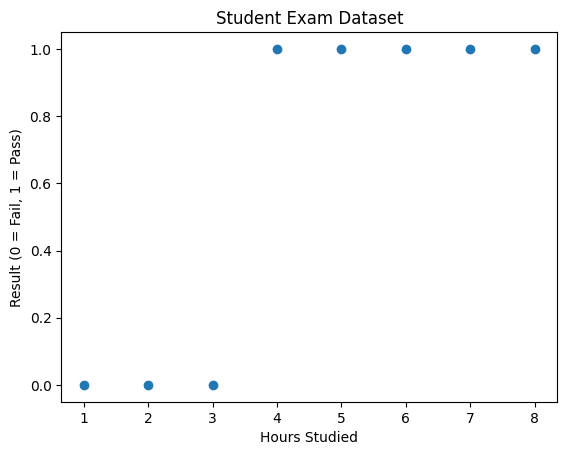

In [4]:

# Plot the dataset using a scatter plot

plt.scatter(X, y)

# Label for x-axis
plt.xlabel("Hours Studied")

# Label for y-axis
plt.ylabel("Result (0 = Fail, 1 = Pass)")

# Title of the graph
plt.title("Student Exam Dataset")

# Show the graph
plt.show()

# 🧪 Step 3 — Train Logistic Regression (With Default Regularization)


In [ ]:
# Create the logistic regression model

# By default, sklearn uses L2 regularization
model = LogisticRegression()


# Train the model using our dataset
# fit() means "learn patterns from the data"
model.fit(X, y)
# Now the model has learned the relationship between hours studied and exam results

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# 🧪 Step 4 — Inspect Model Weights


In [6]:
# Now we check the weights learned by the model.

# Print the learned weight
print("Model weight:", model.coef_)


# Print the bias term
print("Model bias:", model.intercept_)

Model weight: [[1.15590815]]
Model bias: [-4.01852428]


Meaning the model learned an equation like:

```text
z = 1.15 × hours − 4.0
```

These weights are **controlled by regularization** so they don't become too large.

# 🧪 Step 5 — Change Regularization Strength


In Scikit-Learn, the regularization strength is controlled using **C**.

Important relationship:

```text
C = 1 / λ
```

Meaning:

| C Value | Regularization        |
| ------- | --------------------- |
| Small C | Strong regularization |
| Large C | Weak regularization   |

### Example — Strong Regularization


In [7]:
# Create a logistic regression model with strong regularization

model_strong = LogisticRegression(C=0.1)
# Train the model
model_strong.fit(X, y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

```text
C = 0.1
```
This forces the model to keep **smaller weights**.

### Example — Weak Regularization


In [8]:
# Create a logistic regression model with weak regularization

model_weak = LogisticRegression(C=100)
# Train the model
model_weak.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

```text
C = 100
```

Now the model has **much more freedom**.
Weights may become larger.

# 🧪 Step 6 — Compare the Weights


In [9]:
# Print weights for comparison

print("Strong Regularization Weight:", model_strong.coef_)

print("Weak Regularization Weight:", model_weak.coef_)

Strong Regularization Weight: [[0.39922045]]
Weak Regularization Weight: [[5.65232483]]


```text
Strong Regularization → smaller weights
Weak Regularization → larger weights
```

# 📊 Visualizing the Effect of Regularization


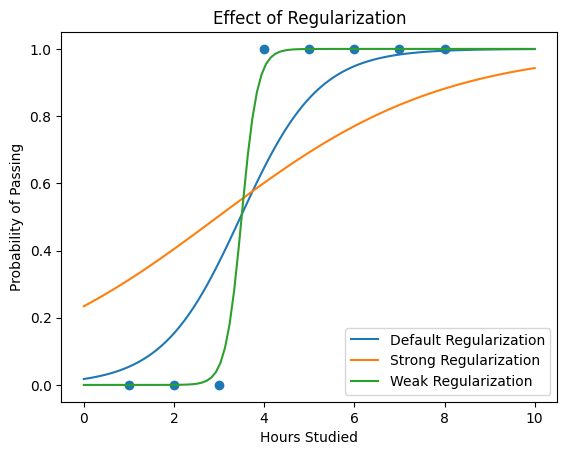

In [10]:
# Now we plot how the prediction curves change.

# Create many input values between 0 and 10
x_test = np.linspace(0,10,100).reshape(-1,1)


# Predict probability of passing
prob_default = model.predict_proba(x_test)[:,1]

prob_strong = model_strong.predict_proba(x_test)[:,1]

prob_weak = model_weak.predict_proba(x_test)[:,1]


# Plot the curves

plt.plot(x_test, prob_default, label="Default Regularization")
plt.plot(x_test, prob_strong, label="Strong Regularization")
plt.plot(x_test, prob_weak, label="Weak Regularization")


# Plot original data points
plt.scatter(X,y)
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Effect of Regularization")
plt.legend()
plt.show()


# 🤖 How Milo Uses Regularization

Inside the algorithm, Milo does this:

```text
1. Calculate Log Loss
2. Add penalty for large weights
3. Try different weights
4. Choose weights that minimize total loss
```

This keeps the model **simple and stable**.



# 🧪 Example — Strong Regularization

```python
model = LogisticRegression(
    penalty='l2',   # Use ridge regularization
    C=0.1           # Strong regularization
)
```

Effect:

```
Weights become smaller
```

Model becomes **simpler**.

---




---

# 🧠 Extra


```text
What happens if C becomes extremely large?
```

Example:

```
C = 1000
```

Regularization becomes **almost zero**.

Model may **overfit**.

---





# 📊 Visual Comparison

![Image](https://www.researchgate.net/publication/339898869/figure/fig3/AS%3A868466835861506%401584070037154/Decision-surface-comparison-among-unsupervised-models-and-their-pseudo-supervised.png)

![Image](https://media.licdn.com/dms/image/v2/C5112AQEfrtKO_lQkAg/article-inline_image-shrink_1000_1488/article-inline_image-shrink_1000_1488/0/1570861616783?e=1771459200\&t=M8GF3cGPZgAwfPk5bkRXRWcxkBIHY77P78T_gtGK2oI\&v=beta)

![Image](https://codefinity-content-media.s3.eu-west-1.amazonaws.com/b71ff7ac-3932-41d2-a4d8-060e24b00129/overfitting_lr.gif)

![Image](https://codefinity-content-media.s3.eu-west-1.amazonaws.com/b71ff7ac-3932-41d2-a4d8-060e24b00129/PolyFeaturesBoundaries.gif)

We clearly see:

| Case              | Boundary |
| ----------------- | -------- |
| No regularization | Complex  |
| Regularized       | Smooth   |

---



# 🧪 Student Practice


```python
model1 = LogisticRegression(C=100)
model2 = LogisticRegression(C=1)
model3 = LogisticRegression(C=0.01)
```

Ask them:

```
Which model overfits?
Which model is smoothest?
```

They will **discover regularization themselves**.

---

# 🎓 What We Now Know

We understand:

✔ Logistic Regression
✔ Sigmoid Function
✔ Probability Prediction
✔ Log Loss
✔ Gradient Descent
✔ Scikit-Learn Implementation
✔ Multiclass Logistic Regression
✔ Regularization (L1 & L2)

This completes **Logistic Regression fully**.
